# Experiment (v0): SSFP PixelByPixel DeepSSFP Model

Epoch 0/100 - loss: 4.26e-04 - val_loss: 6.42e-06
Epoch 10/100 - loss: 2.38e-06 - val_loss: 1.92e-06
Epoch 20/100 - loss: 2.24e-06 - val_loss: 2.06e-06
Epoch 30/100 - loss: 2.04e-06 - val_loss: 3.24e-06
Epoch 40/100 - loss: 1.65e-06 - val_loss: 1.55e-06
Epoch 50/100 - loss: 1.80e-06 - val_loss: 4.08e-06
Epoch 60/100 - loss: 1.42e-06 - val_loss: 1.90e-06
Epoch 70/100 - loss: 1.37e-06 - val_loss: 4.33e-06
Epoch 80/100 - loss: 1.22e-06 - val_loss: 1.19e-06
Epoch 90/100 - loss: 1.49e-06 - val_loss: 7.83e-07


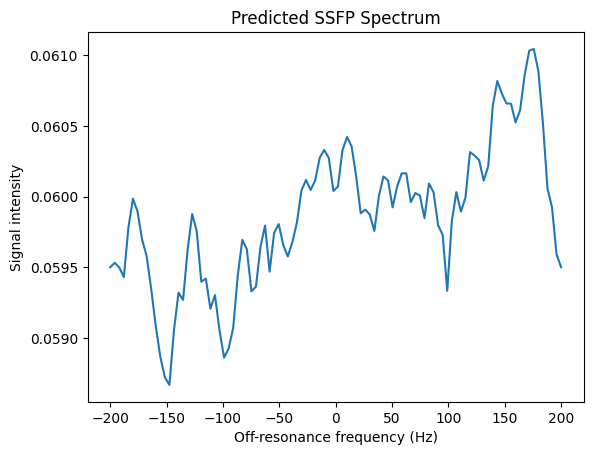

In [46]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from deepssfp import ssfp, recon

# Generate training data
def generate_training_data(num_samples=10000):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    npcs = 4
    pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M)
        y.append(np.sqrt(np.mean(np.abs(M)**2)))
    
    return np.array(X), np.array(y)

# Create the model
def create_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(4,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")


# Train the model
def train_model(model, X, y, epochs=100, batch_size=32, print_every_n=10):
    print_callback = PrintEveryNEpoch(print_every_n)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[print_callback], verbose=0)
    return history

# Use the model to predict SSFP spectrum
def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f):
    npcs = 4
    pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    spectrum = []
    for freq in f:
        M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=freq)
        spectrum.append(model.predict(M.reshape(1, -1), verbose=0)[0, 0])
    
    return np.array(spectrum)

# Example usage
def run():
    # Generate training data
    X_train, y_train = generate_training_data()
    
    # Create and train the model
    model = create_model()
    history = train_model(model, X_train, y_train)
    
    # Generate SSFP spectrum using the trained model
    T1, T2 = 1.2, 0.035
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)
    
    predicted_spectrum = predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f)
    
    # Plot the results
    import matplotlib.pyplot as plt
    plt.plot(f, predicted_spectrum)
    plt.xlabel('Off-resonance frequency (Hz)')
    plt.ylabel('Signal intensity')
    plt.title('Predicted SSFP Spectrum')
    plt.show()

run()

# Experiment (v1): SSFP PixelByPixel DeepSSFP 
- with 2PC and 4PC data model versions

Epoch 0/100 - loss: 2.22e-04 - val_loss: 9.76e-06
Epoch 10/100 - loss: 2.45e-06 - val_loss: 2.12e-06
Epoch 20/100 - loss: 2.87e-06 - val_loss: 3.71e-06
Epoch 30/100 - loss: 2.86e-06 - val_loss: 3.10e-06
Epoch 40/100 - loss: 2.48e-06 - val_loss: 1.82e-06
Epoch 50/100 - loss: 2.81e-06 - val_loss: 2.12e-06
Epoch 60/100 - loss: 2.03e-06 - val_loss: 2.04e-06
Epoch 70/100 - loss: 2.09e-06 - val_loss: 1.87e-06
Epoch 80/100 - loss: 1.85e-06 - val_loss: 1.74e-06
Epoch 90/100 - loss: 1.67e-06 - val_loss: 2.08e-06
Epoch 0/100 - loss: 1.23e-03 - val_loss: 4.90e-04
Epoch 10/100 - loss: 2.65e-04 - val_loss: 2.10e-04
Epoch 20/100 - loss: 1.65e-04 - val_loss: 1.43e-04
Epoch 30/100 - loss: 1.51e-04 - val_loss: 1.69e-04
Epoch 40/100 - loss: 1.50e-04 - val_loss: 1.22e-04
Epoch 50/100 - loss: 1.37e-04 - val_loss: 1.15e-04
Epoch 60/100 - loss: 1.33e-04 - val_loss: 1.38e-04
Epoch 70/100 - loss: 1.19e-04 - val_loss: 1.42e-04
Epoch 80/100 - loss: 1.23e-04 - val_loss: 1.50e-04
Epoch 90/100 - loss: 1.23e-04 - v

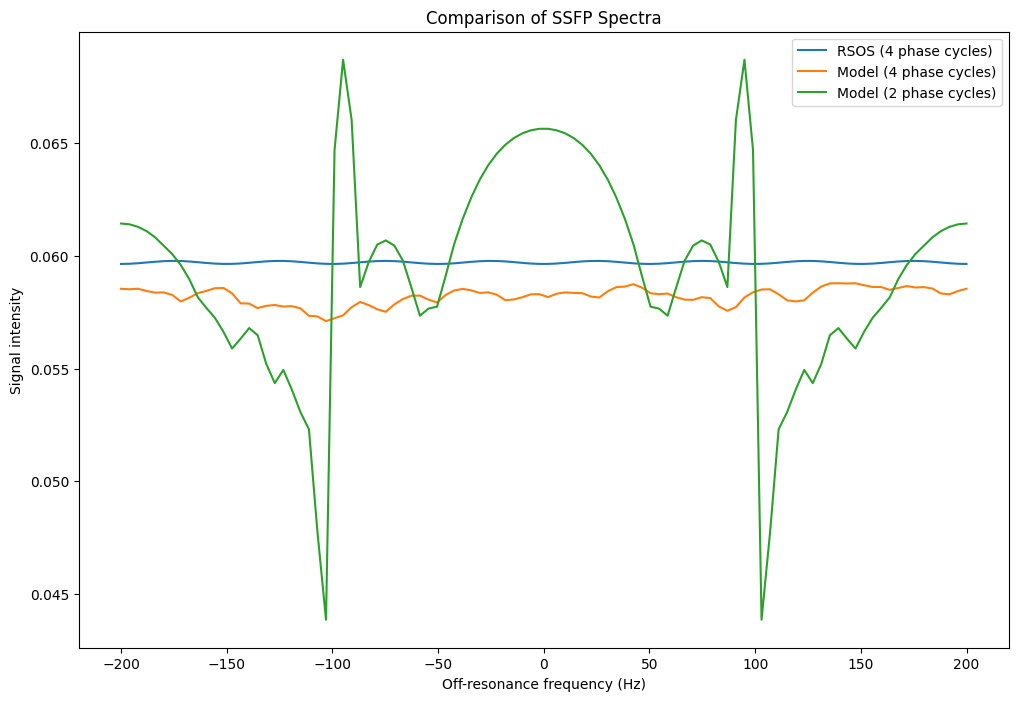

MSE (4 phase cycles): 2.385750769175362e-06
MSE (2 phase cycles): 2.137486048997474e-05


In [47]:
import sys
sys.path.insert(0, '../../')
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from deepssfp import ssfp, recon

def generate_training_data(num_samples=10000, num_pcs=2):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2)))
    
    return np.array(X), np.array(y)

def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")

def train_model(model, X, y, epochs=100, batch_size=32, print_every_n=10):
    print_callback = PrintEveryNEpoch(print_every_n)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[print_callback], verbose=0)
    return history

def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f, num_pcs):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    spectrum = []
    for freq in f:
        M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=freq)
        spectrum.append(model.predict(M.reshape(1, -1), verbose=0)[0, 0])
    
    return np.array(spectrum)

# Generate data and train models
X_train_4pc, y_train_4pc = generate_training_data(num_samples=10000, num_pcs=4)
X_train_2pc, y_train_2pc = generate_training_data(num_samples=10000, num_pcs=2)

model_4pc = create_model(input_shape=(4,))
model_2pc = create_model(input_shape=(2,))

history_4pc = train_model(model_4pc, X_train_4pc, y_train_4pc)
history_2pc = train_model(model_2pc, X_train_2pc, y_train_2pc)

# Generate SSFP spectrum for comparison
T1, T2 = 1.2, 0.035
TR, alpha = 5e-3, np.deg2rad(30)
TE = TR / 2.0
BetaMax = 2 * np.pi
beta = np.linspace(-BetaMax, BetaMax, 100)
f = beta / TR / (2 * np.pi)

predicted_spectrum_4pc = predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4)
predicted_spectrum_2pc = predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2)

# Calculate RSOS spectrum
M_4pc = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
rsos_spectrum = np.sqrt(np.mean(np.abs(M_4pc)**2, axis=1))

# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)')
plt.plot(f, predicted_spectrum_4pc, label='Model (4 phase cycles)')
plt.plot(f, predicted_spectrum_2pc, label='Model (2 phase cycles)')
plt.xlabel('Off-resonance frequency (Hz)')
plt.ylabel('Signal intensity')
plt.title('Comparison of SSFP Spectra')
plt.legend()
plt.show()

# Calculate and print mean squared errors
mse_4pc = np.mean((rsos_spectrum - predicted_spectrum_4pc)**2)
mse_2pc = np.mean((rsos_spectrum - predicted_spectrum_2pc)**2)
print(f"MSE (4 phase cycles): {mse_4pc}")
print(f"MSE (2 phase cycles): {mse_2pc}")

# Experiment (v2): SSFP PixelByPixel DeepSSFP Model
- Uses standard scaler to normalize data
- Improved model architecture with batch normalization
- Early stopping
- Added noise
- Academic metrics i.e. MSE, PSNR, SSIM
- Predict SSFP spectrum with multiple acquisitions
- Printing Loss Metrics Every N Epochs
- Log loss plots


Creating training data...
Completed in 18.53 seconds.
Training 4PC model...
Epoch 0/200 - loss: 4.66e-02 - val_loss: 4.30e-03
Epoch 10/200 - loss: 3.58e-04 - val_loss: 2.83e-04
Epoch 20/200 - loss: 1.81e-04 - val_loss: 1.42e-04
Epoch 30/200 - loss: 1.41e-04 - val_loss: 4.25e-05
Epoch 40/200 - loss: 1.13e-04 - val_loss: 5.69e-05
Epoch 50/200 - loss: 1.06e-04 - val_loss: 5.96e-05
Epoch 60/200 - loss: 9.07e-05 - val_loss: 1.81e-05
Epoch 70/200 - loss: 7.88e-05 - val_loss: 3.02e-05
Epoch 80/200 - loss: 7.68e-05 - val_loss: 9.53e-05
Completed in 126.18 seconds.
Training 2PC model...
Epoch 0/200 - loss: 4.43e-02 - val_loss: 4.80e-03
Epoch 10/200 - loss: 3.76e-04 - val_loss: 2.15e-04
Epoch 20/200 - loss: 2.02e-04 - val_loss: 9.03e-05
Epoch 30/200 - loss: 1.75e-04 - val_loss: 6.79e-05
Epoch 40/200 - loss: 1.15e-04 - val_loss: 4.49e-05
Epoch 50/200 - loss: 9.67e-05 - val_loss: 6.27e-05
Epoch 60/200 - loss: 9.24e-05 - val_loss: 4.09e-05
Epoch 70/200 - loss: 8.82e-05 - val_loss: 2.29e-05
Epoch 80

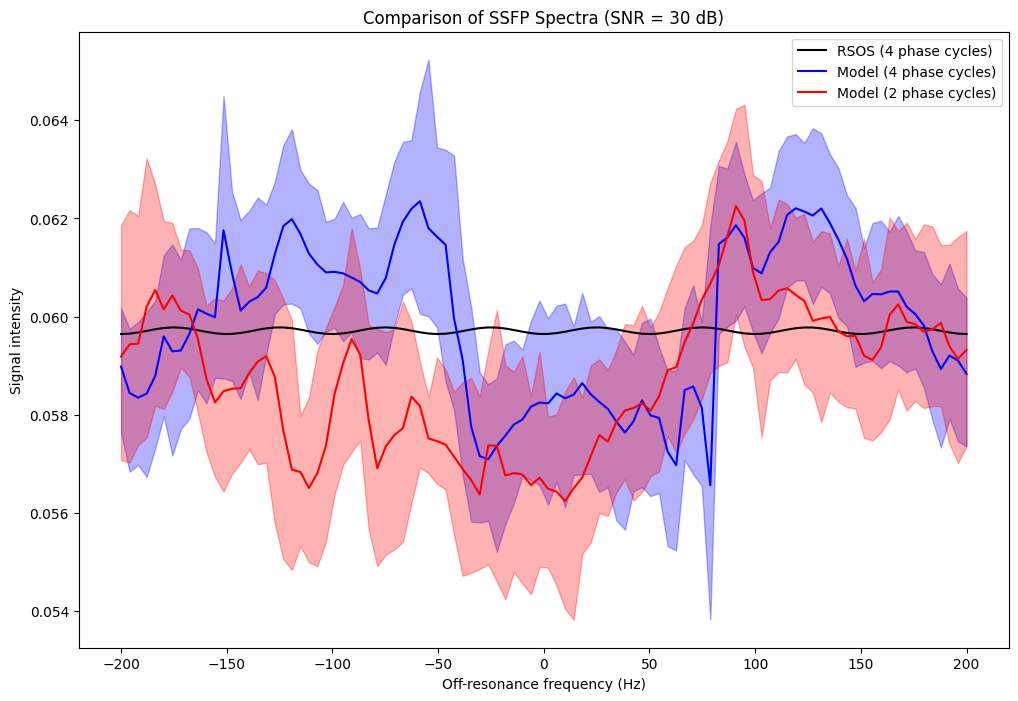

Metrics for 4 phase cycle model:
MSE: 2.49e-06
RMSE: 1.58e-03
MAE: 1.41e-03
R2: -1.07e+03
Correlation: -5.68e-02
NRMSE: 1.16e+01

Metrics for 2 phase cycle model:
MSE: 3.03e-06
RMSE: 1.74e-03
MAE: 1.38e-03
R2: -1.31e+03
Correlation: 6.21e-02
NRMSE: 1.28e+01

Paired t-test results:
t-statistic: -1.44e+01
p-value: 5.45e-26


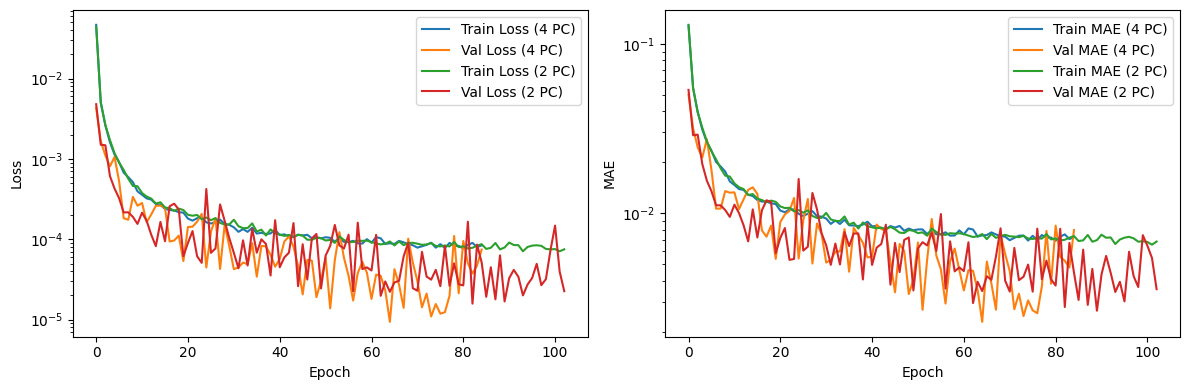

In [44]:
import sys
sys.path.insert(0, '../../')
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, ttest_rel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from deepssfp import ssfp, recon

def add_noise(signal, snr):
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(snr/10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

def generate_training_data(num_samples=10000, num_pcs=2, snr=30):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_input = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        M_input_noisy = add_noise(M_input, snr)
        X.append(np.concatenate([np.real(M_input_noisy), np.imag(M_input_noisy)]))
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        M_4pc_noisy = add_noise(M_4pc, snr)
        y.append(np.sqrt(np.mean(np.abs(M_4pc_noisy)**2)))
    
    return np.array(X), np.array(y)

def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")

def train_model(X, y, epochs=200, batch_size=32, validation_split=0.2, print_every_n=10):
    model = create_model(input_shape=(X.shape[1],))
    
    early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
    print_callback = PrintEveryNEpoch(print_every_n)
    
    history = model.fit(X, y, 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        validation_split=validation_split,
                        callbacks=[early_stopping, print_callback],
                        verbose=0)
    
    return model, history

def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f, num_pcs, scaler, snr):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    # Generate SSFP signals for all frequencies at once
    M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=f)
    
    # Add noise to all signals
    M_noisy = add_noise(M, snr)
    
    # Reshape and prepare input for the model
    M_input = np.concatenate([np.real(M_noisy), np.imag(M_noisy)], axis=1)
    M_scaled = scaler.transform(M_input)
    
    # Predict all spectra at once
    predictions = model.predict(M_scaled, verbose=0)
    
    return predictions.flatten()

def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert to float64 to ensure compatibility with pearsonr
    y_true_float = y_true.astype(np.float64)
    y_pred_float = y_pred.astype(np.float64)
    
    # Check for NaN or infinite values
    valid_indices = np.isfinite(y_true_float) & np.isfinite(y_pred_float)
    if np.sum(valid_indices) > 1:  # Need at least 2 valid points for correlation
        corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])
    else:
        corr = np.nan
    
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Correlation': corr, 'NRMSE': nrmse}

def run(snr = 30, num_samples = 20000, epochs = 200, batch_size = 32, print_every_n = 10):

    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Generate data and preprocess
    print('Creating training data...')
    start_time = time.time()
    X_4pc, y_4pc = generate_training_data(num_samples=num_samples, num_pcs=4, snr=snr)
    X_2pc, y_2pc = generate_training_data(num_samples=num_samples, num_pcs=2, snr=snr)
    #X_2pc = X_4pc[:, [0, 2, 4, 6]]; y_2pc = y_4pc
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    scaler_4pc = StandardScaler().fit(X_4pc)
    scaler_2pc = StandardScaler().fit(X_2pc)

    X_4pc_scaled = scaler_4pc.transform(X_4pc)
    X_2pc_scaled = scaler_2pc.transform(X_2pc)

    # Train models
    print('Training 4PC model...')
    start_time = time.time()
    model_4pc, history_4pc = train_model(X_4pc_scaled, y_4pc, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    print('Training 2PC model...')
    start_time = time.time()
    model_2pc, history_2pc = train_model(X_2pc_scaled, y_2pc, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    # Generate SSFP spectra for comparison
    T1, T2 = 1.2, 0.035
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    num_samples = 100
    print('Predicting spectra...')
    start_time = time.time()
    predicted_spectra_4pc = np.array([predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr) for _ in range(num_samples)])
    predicted_spectra_2pc = np.array([predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr) for _ in range(num_samples)])
    print('Prediction completed in %.2f seconds.' % (time.time() - start_time))

    # Calculate average and confidence intervals
    avg_spectrum_4pc = np.mean(predicted_spectra_4pc, axis=0)
    ci_4pc = np.percentile(predicted_spectra_4pc, [2.5, 97.5], axis=0)

    avg_spectrum_2pc = np.mean(predicted_spectra_2pc, axis=0)
    ci_2pc = np.percentile(predicted_spectra_2pc, [2.5, 97.5], axis=0)

    # Calculate RSOS spectrum
    rsos_spectrum = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
    rsos_spectrum = np.sqrt(np.mean(np.abs(rsos_spectrum)**2, axis=1))

    # Plot the results
    plt.figure(figsize=(12, 8))
    plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
    plt.plot(f, avg_spectrum_4pc, label='Model (4 phase cycles)', color='blue')
    plt.fill_between(f, ci_4pc[0], ci_4pc[1], alpha=0.3, color='blue')
    plt.plot(f, avg_spectrum_2pc, label='Model (2 phase cycles)', color='red')
    plt.fill_between(f, ci_2pc[0], ci_2pc[1], alpha=0.3, color='red')
    plt.xlabel('Off-resonance frequency (Hz)')
    plt.ylabel('Signal intensity')
    plt.title(f'Comparison of SSFP Spectra (SNR = {snr} dB)')
    plt.legend()
    plt.show()

    # Calculate and print metrics
    metrics_4pc = calculate_metrics(rsos_spectrum, avg_spectrum_4pc)
    metrics_2pc = calculate_metrics(rsos_spectrum, avg_spectrum_2pc)

    print("Metrics for 4 phase cycle model:")
    for metric, value in metrics_4pc.items():
        print(f"{metric}: {value:.2e}")

    print("\nMetrics for 2 phase cycle model:")
    for metric, value in metrics_2pc.items():
        print(f"{metric}: {value:.2e}")

    # Statistical analysis
    t_statistic, p_value = ttest_rel(
        np.mean((rsos_spectrum - predicted_spectra_4pc)**2, axis=1),
        np.mean((rsos_spectrum - predicted_spectra_2pc)**2, axis=1)
    )

    print(f"\nPaired t-test results:")
    print(f"t-statistic: {t_statistic:.2e}")
    print(f"p-value: {p_value:.2e}")

    # Plot average training history
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    plt.semilogy(history_4pc.history['loss'], label='Train Loss (4 PC)')
    plt.semilogy(history_4pc.history['val_loss'], label='Val Loss (4 PC)')
    plt.semilogy(history_2pc.history['loss'], label='Train Loss (2 PC)')
    plt.semilogy(history_2pc.history['val_loss'], label='Val Loss (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(122)
    plt.semilogy(history_4pc.history['mae'], label='Train MAE (4 PC)')
    plt.semilogy(history_4pc.history['val_mae'], label='Val MAE (4 PC)')
    plt.semilogy(history_2pc.history['mae'], label='Train MAE (2 PC)')
    plt.semilogy(history_2pc.history['val_mae'], label='Val MAE (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()

run()

# Experiment (v5): SSFP PixelByPixel DeepSSFP Model
- Training with various T1 and T2 values
- Comparison with common tissue types
- Box plot of performance metrics across folds
- Statistical analysis

Training fold 1/5
Epoch 0/200 - loss: 5.53e-02 - val_loss: 7.34e-03
Epoch 10/200 - loss: 9.67e-04 - val_loss: 3.63e-04
Epoch 20/200 - loss: 6.10e-04 - val_loss: 2.05e-04
Epoch 30/200 - loss: 5.17e-04 - val_loss: 1.50e-04
Epoch 40/200 - loss: 4.96e-04 - val_loss: 2.26e-04
Epoch 50/200 - loss: 4.00e-04 - val_loss: 9.47e-05
Epoch 60/200 - loss: 3.81e-04 - val_loss: 2.03e-04
Epoch 70/200 - loss: 3.55e-04 - val_loss: 5.59e-05
Epoch 80/200 - loss: 3.26e-04 - val_loss: 7.95e-05
Epoch 90/200 - loss: 3.03e-04 - val_loss: 1.32e-04
Epoch 100/200 - loss: 3.49e-04 - val_loss: 1.15e-04
Epoch 110/200 - loss: 3.24e-04 - val_loss: 5.78e-05
Epoch 120/200 - loss: 3.04e-04 - val_loss: 1.60e-04
Epoch 130/200 - loss: 2.84e-04 - val_loss: 1.35e-04
125/125 [==============================] - 0s 903us/step
Training fold 2/5
Epoch 0/200 - loss: 5.90e-02 - val_loss: 5.85e-03
Epoch 10/200 - loss: 9.29e-04 - val_loss: 7.10e-04
Epoch 20/200 - loss: 5.84e-04 - val_loss: 1.90e-04
Epoch 30/200 - loss: 5.12e-04 - val_lo

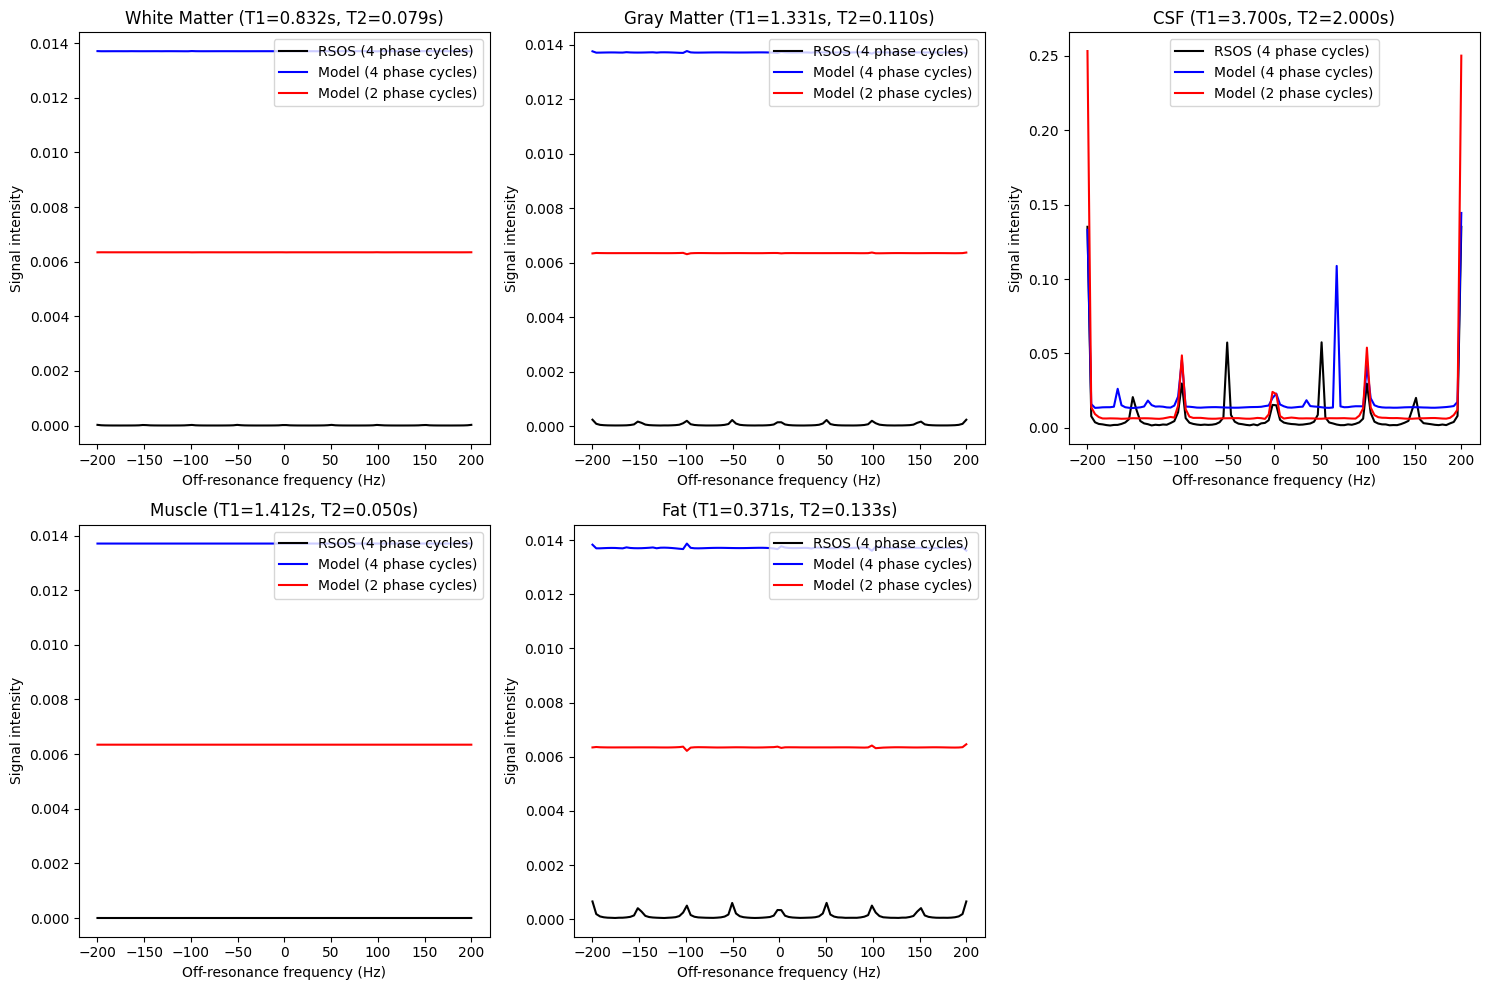

C:\Users\mmend\AppData\Local\Temp\ipykernel_20904\2172142682.py:224: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_4pc, data_2pc], labels=['4 PC', '2 PC'])
C:\Users\mmend\AppData\Local\Temp\ipykernel_20904\2172142682.py:224: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_4pc, data_2pc], labels=['4 PC', '2 PC'])
C:\Users\mmend\AppData\Local\Temp\ipykernel_20904\2172142682.py:224: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_4pc, data_2pc], labels=['4 PC', '2 PC'])
C:\Users\mmend\AppData\Local\Temp\ipykernel_20904\2172142682.py:224: MatplotlibDeprecationWarning: The 

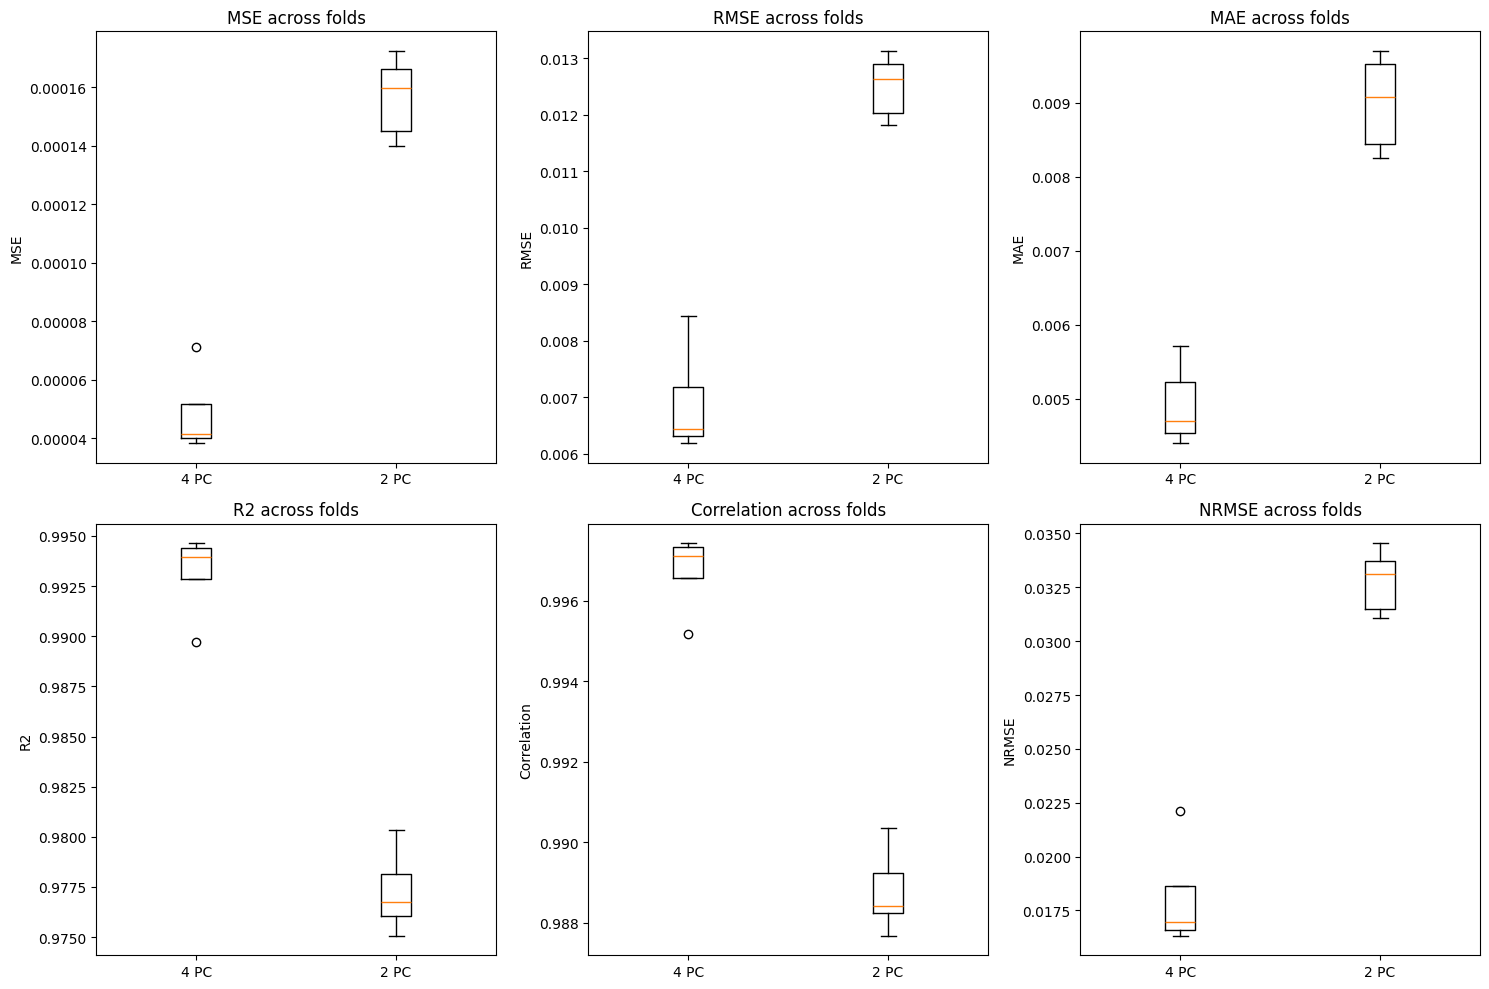


Paired t-test results:
MSE:
  t-statistic: -1.01e+01
  p-value: 5.33e-04
RMSE:
  t-statistic: -9.60e+00
  p-value: 6.58e-04
MAE:
  t-statistic: -8.87e+00
  p-value: 8.94e-04
R2:
  t-statistic: 1.08e+01
  p-value: 4.14e-04
Correlation:
  t-statistic: 1.13e+01
  p-value: 3.54e-04
NRMSE:
  t-statistic: -9.61e+00
  p-value: 6.54e-04


c:\Users\mmend\.conda\envs\ml\lib\site-packages\numpy\core\_methods.py:164: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = asanyarray(a)


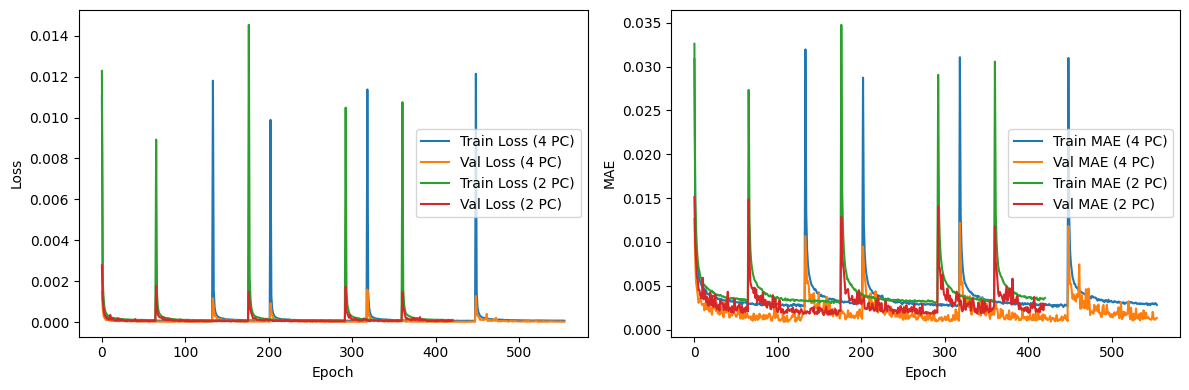

In [6]:
import sys
sys.path.insert(0, '../../')
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, ttest_rel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from deepssfp import ssfp, recon

def add_noise(signal, snr):
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(snr/10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

def generate_training_data(num_samples=10000, num_pcs=2, snr=30):
    # Generate realistic T1 and T2 values
    T1 = np.random.uniform(0.1, 3.0, num_samples)  # Range from 100ms to 3000ms
    T2 = np.random.uniform(0.01, 0.5, num_samples)  # Range from 10ms to 500ms
    
    # Ensure T2 <= T1
    T2 = np.minimum(T2, T1)
    
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_input = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        M_input_noisy = add_noise(M_input, snr)
        X.append(np.concatenate([np.real(M_input_noisy), np.imag(M_input_noisy)]))
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        M_4pc_noisy = add_noise(M_4pc, snr)
        y.append(np.sqrt(np.mean(np.abs(M_4pc_noisy)**2)))
    
    return np.array(X), np.array(y)

def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")


def train_model_cv(X, y, n_splits=5, epochs=200, batch_size=32, print_every_n=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    histories = []
    models = []
    val_metrics = []

    for fold, (train_index, val_index) in enumerate(kf.split(X)):
        print(f"Training fold {fold + 1}/{n_splits}")
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model = create_model(input_shape=(X.shape[1],))
        
        early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
        print_callback = PrintEveryNEpoch(print_every_n)
        
        history = model.fit(X_train, y_train, 
                            epochs=epochs, 
                            batch_size=batch_size, 
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping, print_callback],
                            verbose=0)
        
        histories.append(history)
        models.append(model)
        
        # Calculate validation metrics
        y_pred = model.predict(X_val)
        metrics = calculate_metrics(y_val, y_pred)
        val_metrics.append(metrics)

    return models, histories, val_metrics

def predict_ssfp_spectrum(models, T1, T2, TR, alpha, TE, f, num_pcs, scaler, snr):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    spectra = []
    for model in models:
        spectrum = []
        for freq in f:
            M = ssfp.ssfp(T1, T2, TR, alpha, TE, pcs, f0=freq)
            M_noisy = add_noise(M, snr)
            M_input = np.concatenate([np.real(M_noisy), np.imag(M_noisy)]).reshape(1, -1)
            M_scaled = scaler.transform(M_input)
            spectrum.append(model.predict(M_scaled)[0, 0])
        spectra.append(spectrum)
    
    return np.array(spectra)

def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert to float64 to ensure compatibility with pearsonr
    y_true_float = y_true.astype(np.float64)
    y_pred_float = y_pred.astype(np.float64)
    
    # Check for NaN or infinite values
    valid_indices = np.isfinite(y_true_float) & np.isfinite(y_pred_float)
    if np.sum(valid_indices) > 1:  # Need at least 2 valid points for correlation
        corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])
    else:
        corr = np.nan
    
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Correlation': corr, 'NRMSE': nrmse}

# Main execution
if __name__ == "__main__":
    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Parameters
    snr = 30
    num_samples = 20000
    n_splits = 5
    epochs = 200
    batch_size = 32
    print_every_n = 10

    # Generate data and preprocess
    X_4pc, y_4pc = generate_training_data(num_samples=num_samples, num_pcs=4, snr=snr)
    X_2pc, y_2pc = generate_training_data(num_samples=num_samples, num_pcs=2, snr=snr)

    scaler_4pc = StandardScaler().fit(X_4pc)
    scaler_2pc = StandardScaler().fit(X_2pc)

    X_4pc_scaled = scaler_4pc.transform(X_4pc)
    X_2pc_scaled = scaler_2pc.transform(X_2pc)

    # Train models with cross-validation
    models_4pc, histories_4pc, metrics_4pc = train_model_cv(X_4pc_scaled, y_4pc, n_splits=n_splits, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    models_2pc, histories_2pc, metrics_2pc = train_model_cv(X_2pc_scaled, y_2pc, n_splits=n_splits, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)

    # Common tissue types (T1 and T2 values in seconds at 3T)
    tissues = {
        'White Matter': (0.832, 0.079),
        'Gray Matter': (1.331, 0.110),
        'CSF': (3.700, 2.000),
        'Muscle': (1.412, 0.050),
        'Fat': (0.371, 0.133)
    }

    # Generate SSFP spectra for common tissue types
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    plt.figure(figsize=(15, 10))
    for i, (tissue, (T1, T2)) in enumerate(tissues.items()):
        predicted_spectra_4pc = predict_ssfp_spectrum(models_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr)
        predicted_spectra_2pc = predict_ssfp_spectrum(models_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr)

        avg_spectrum_4pc = np.mean(predicted_spectra_4pc, axis=0)
        avg_spectrum_2pc = np.mean(predicted_spectra_2pc, axis=0)

        M_4pc = ssfp.ssfp(T1, T2, TR, alpha, TE, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
        M_4pc_noisy = add_noise(M_4pc, snr)
        rsos_spectrum = np.sqrt(np.mean(np.abs(M_4pc_noisy)**2, axis=1))

        plt.subplot(2, 3, i+1)
        plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
        plt.plot(f, avg_spectrum_4pc, label='Model (4 phase cycles)', color='blue')
        plt.plot(f, avg_spectrum_2pc, label='Model (2 phase cycles)', color='red')
        plt.xlabel('Off-resonance frequency (Hz)')
        plt.ylabel('Signal intensity')
        plt.title(f'{tissue} (T1={T1:.3f}s, T2={T2:.3f}s)')
        plt.legend()

    plt.tight_layout()
    plt.show()

    # Box plot of performance metrics across folds
    metrics_names = ['MSE', 'RMSE', 'MAE', 'R2', 'Correlation', 'NRMSE']
    
    plt.figure(figsize=(15, 10))
    for i, metric in enumerate(metrics_names):
        plt.subplot(2, 3, i+1)
        data_4pc = [m[metric] for m in metrics_4pc]
        data_2pc = [m[metric] for m in metrics_2pc]
        plt.boxplot([data_4pc, data_2pc], labels=['4 PC', '2 PC'])
        plt.title(f'{metric} across folds')
        plt.ylabel(metric)
    
    plt.tight_layout()
    plt.show()

    # Statistical analysis
    t_statistics = {}
    p_values = {}
    for metric in metrics_names:
        data_4pc = [m[metric] for m in metrics_4pc]
        data_2pc = [m[metric] for m in metrics_2pc]
        t_statistic, p_value = ttest_rel(data_4pc, data_2pc)
        t_statistics[metric] = t_statistic
        p_values[metric] = p_value

    print("\nPaired t-test results:")
    for metric in metrics_names:
        print(f"{metric}:")
        print(f"  t-statistic: {t_statistics[metric]:.2e}")
        print(f"  p-value: {p_values[metric]:.2e}")

    # Plot average training history
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    plt.plot(np.mean([h.history['loss'] for h in histories_4pc], axis=0), label='Train Loss (4 PC)')
    plt.plot(np.mean([h.history['val_loss'] for h in histories_4pc], axis=0), label='Val Loss (4 PC)')
    plt.plot(np.mean([h.history['loss'] for h in histories_2pc], axis=0), label='Train Loss (2 PC)')
    plt.plot(np.mean([h.history['val_loss'] for h in histories_2pc], axis=0), label='Val Loss (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(122)
    plt.plot(np.mean([h.history['mae'] for h in histories_4pc], axis=0), label='Train MAE (4 PC)')
    plt.plot(np.mean([h.history['val_mae'] for h in histories_4pc], axis=0), label='Val MAE (4 PC)')
    plt.plot(np.mean([h.history['mae'] for h in histories_2pc], axis=0), label='Train MAE (2 PC)')
    plt.plot(np.mean([h.history['val_mae'] for h in histories_2pc], axis=0), label='Val MAE (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Experiment (v5): SSFP PixelByPixel DeepSSFP Model
- Architectures: Dense, ResNet, Attention, Diffusion

In [8]:
import sys
sys.path.insert(0, '../../')
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, ttest_rel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from deepssfp import ssfp, recon

def add_noise(signal, snr):
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(snr/10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

def generate_training_data(num_samples=10000, num_pcs=2, snr=30):
    T1 = np.random.uniform(0.1, 3.0, num_samples)  # Range from 100ms to 3000ms
    T2 = np.random.uniform(0.01, 0.5, num_samples)  # Range from 10ms to 500ms
    T2 = np.minimum(T2, T1)  # Ensure T2 <= T1
    
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_input = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        M_input_noisy = add_noise(M_input, snr)
        X.append(np.concatenate([np.real(M_input_noisy), np.imag(M_input_noisy)]))
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        M_4pc_noisy = add_noise(M_4pc, snr)
        y.append(np.sqrt(np.mean(np.abs(M_4pc_noisy)**2)))
    
    return np.array(X), np.array(y)

def create_dense_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_resnet_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Dense(64, activation='relu')(inputs)
    x = keras.layers.BatchNormalization()(x)
    
    for _ in range(3):  # Number of residual blocks
        residual = x
        x = keras.layers.Dense(64, activation='relu')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Dense(64, activation='relu')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Add()([x, residual])
    
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_attention_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Dense(64, activation='relu')(inputs)
    x = keras.layers.BatchNormalization()(x)
    
    # Self-attention layer
    query = keras.layers.Dense(64)(x)
    key = keras.layers.Dense(64)(x)
    value = keras.layers.Dense(64)(x)
    attention_scores = tf.matmul(query, key, transpose_b=True)
    attention_scores = tf.nn.softmax(attention_scores, axis=-1)
    attention_output = tf.matmul(attention_scores, value)
    
    x = keras.layers.Concatenate()([x, attention_output])
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_diffusion_model(input_shape, num_steps=10):
    def diffusion_step(x_t, t):
        noise_scale = tf.sqrt(1 - tf.pow(0.9, t))
        signal_scale = tf.sqrt(tf.pow(0.9, t))
        return signal_scale * x_t + noise_scale * tf.random.normal(tf.shape(x_t))

    def reverse_diffusion_step(x_t, t, model):
        predicted_noise = model([x_t, t])
        x_prev = (x_t - tf.sqrt(1 - tf.pow(0.9, t)) * predicted_noise) / tf.sqrt(tf.pow(0.9, t))
        return x_prev

    inputs = keras.Input(shape=input_shape)
    t = keras.Input(shape=(1,))
    
    x = keras.layers.Concatenate()([inputs, t])
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    outputs = keras.layers.Dense(input_shape[0])(x)
    
    noise_predictor = keras.Model(inputs=[inputs, t], outputs=outputs)
    
    def train_step(x):
        t = tf.random.uniform((tf.shape(x)[0], 1), 1, num_steps, dtype=tf.int32)
        noisy_x = diffusion_step(x, tf.cast(t, tf.float32))
        with tf.GradientTape() as tape:
            predicted_noise = noise_predictor([noisy_x, tf.cast(t, tf.float32) / num_steps])
            loss = tf.reduce_mean(tf.square(predicted_noise - x))
        grads = tape.gradient(loss, noise_predictor.trainable_variables)
        optimizer.apply_gradients(zip(grads, noise_predictor.trainable_variables))
        return loss

    def predict(x):
        x_t = tf.random.normal(tf.shape(x))
        for t in range(num_steps, 0, -1):
            x_t = reverse_diffusion_step(x_t, t, noise_predictor)
        return x_t

    model = keras.Model(inputs=inputs, outputs=outputs)
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    model.train_step = train_step
    model.predict = predict
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")

def train_model_cv(X, y, create_model_func, n_splits=5, epochs=200, batch_size=32, print_every_n=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    histories = []
    models = []
    val_metrics = []

    for fold, (train_index, val_index) in enumerate(kf.split(X)):
        print(f"Training fold {fold + 1}/{n_splits}")
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model = create_model_func(input_shape=(X.shape[1],))
        
        early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
        print_callback = PrintEveryNEpoch(print_every_n)
        
        history = model.fit(X_train, y_train, 
                            epochs=epochs, 
                            batch_size=batch_size, 
                            validation_data=(X_val, y_val),
                            callbacks=[early_stopping, print_callback],
                            verbose=0)
        
        histories.append(history)
        models.append(model)
        
        # Calculate validation metrics
        y_pred = model.predict(X_val)
        metrics = calculate_metrics(y_val, y_pred)
        val_metrics.append(metrics)

    return models, histories, val_metrics

def predict_ssfp_spectrum(models, T1, T2, TR, alpha, TE, f, num_pcs, scaler, snr):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    spectra = []
    for model in models:
        spectrum = []
        for freq in f:
            M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=freq)
            M_noisy = add_noise(M, snr)
            M_input = np.concatenate([np.real(M_noisy), np.imag(M_noisy)]).reshape(1, -1)
            M_scaled = scaler.transform(M_input)
            spectrum.append(model.predict(M_scaled)[0, 0])
        spectra.append(spectrum)
    
    return np.array(spectra)

def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert to float64 to ensure compatibility with pearsonr
    y_true_float = y_true.astype(np.float64)
    y_pred_float = y_pred.astype(np.float64)
    
    # Check for NaN or infinite values
    valid_indices = np.isfinite(y_true_float) & np.isfinite(y_pred_float)
    if np.sum(valid_indices) > 1:  # Need at least 2 valid points for correlation
        corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])
    else:
        corr = np.nan
    
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Correlation': corr, 'NRMSE': nrmse}

def run_ssfp_comparison(snr=30, num_samples=20000, n_splits=5, epochs=200, batch_size=32, print_every_n=10):
    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Generate data and preprocess
    X_4pc, y_4pc = generate_training_data(num_samples=num_samples, num_pcs=4, snr=snr)
    X_2pc, y_2pc = generate_training_data(num_samples=num_samples, num_pcs=2, snr=snr)

    scaler_4pc = StandardScaler().fit(X_4pc)
    scaler_2pc = StandardScaler().fit(X_2pc)

    X_4pc_scaled = scaler_4pc.transform(X_4pc)
    X_2pc_scaled = scaler_2pc.transform(X_2pc)

    # Define model architectures
    model_architectures = {
        'Dense': create_dense_model,
        'ResNet': create_resnet_model,
        'Attention': create_attention_model,
        'Diffusion': create_diffusion_model
    }

    results_4pc = {}
    results_2pc = {}

    # Train models with cross-validation
    for name, create_func in model_architectures.items():
        print(f"\nTraining {name} model for 4 phase cycles:")
        models, histories, metrics = train_model_cv(X_4pc_scaled, y_4pc, create_func, n_splits=n_splits, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
        results_4pc[name] = (models, histories, metrics)

        print(f"\nTraining {name} model for 2 phase cycles:")
        models, histories, metrics = train_model_cv(X_2pc_scaled, y_2pc, create_func, n_splits=n_splits, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
        results_2pc[name] = (models, histories, metrics)

    # Common tissue types (T1 and T2 values in seconds at 3T)
    tissues = {
        'White Matter': (0.832, 0.079),
        'Gray Matter': (1.331, 0.110),
        'CSF': (3.700, 2.000),
        'Muscle': (1.412, 0.050),
        'Fat': (0.371, 0.133)
    }

    # Generate SSFP spectra for common tissue types
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    # Plot SSFP spectra for each tissue and model architecture
    for tissue, (T1, T2) in tissues.items():
        plt.figure(figsize=(15, 10))
        for i, (name, (models_4pc, _, _)) in enumerate(results_4pc.items()):
            predicted_spectra_4pc = predict_ssfp_spectrum(models_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr)
            predicted_spectra_2pc = predict_ssfp_spectrum(results_2pc[name][0], T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr)

            avg_spectrum_4pc = np.mean(predicted_spectra_4pc, axis=0)
            avg_spectrum_2pc = np.mean(predicted_spectra_2pc, axis=0)

            M_4pc = ssfp.ssfp(T1, T2, TR, alpha, TE, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
            M_4pc_noisy = add_noise(M_4pc, snr)
            rsos_spectrum = np.sqrt(np.mean(np.abs(M_4pc_noisy)**2, axis=1))

            plt.subplot(2, 2, i+1)
            plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
            plt.plot(f, avg_spectrum_4pc, label='Model 4PC', color='blue')
            plt.plot(f, avg_spectrum_2pc, label='Model 2PC', color='red')
            plt.xlabel('Off-resonance frequency (Hz)')
            plt.ylabel('Signal intensity')
            plt.title(f'{name} - {tissue} (T1={T1:.3f}s, T2={T2:.3f}s)')
            plt.legend()

        plt.tight_layout()
        plt.show()

    # Box plot of performance metrics across folds for each architecture
    metrics_names = ['MSE', 'RMSE', 'MAE', 'R2', 'Correlation', 'NRMSE']
    
    for metric in metrics_names:
        plt.figure(figsize=(15, 6))
        data_4pc = [
            [m[metric] for m in results_4pc[name][2]] for name in model_architectures
        ]
        data_2pc = [
            [m[metric] for m in results_2pc[name][2]] for name in model_architectures
        ]
        
        plt.subplot(121)
        plt.boxplot(data_4pc, labels=list(model_architectures.keys()))
        plt.title(f'{metric} across folds (4 phase cycles)')
        plt.ylabel(metric)
        
        plt.subplot(122)
        plt.boxplot(data_2pc, labels=list(model_architectures.keys()))
        plt.title(f'{metric} across folds (2 phase cycles)')
        plt.ylabel(metric)
        
        plt.tight_layout()
        plt.show()

    # Statistical analysis
    for pc, results in [('4PC', results_4pc), ('2PC', results_2pc)]:
        print(f"\nStatistical analysis for {pc}:")
        for metric in metrics_names:
            print(f"\n{metric}:")
            for name1, (_, _, metrics1) in results.items():
                for name2, (_, _, metrics2) in results.items():
                    if name1 < name2:
                        data1 = [m[metric] for m in metrics1]
                        data2 = [m[metric] for m in metrics2]
                        t_statistic, p_value = ttest_rel(data1, data2)
                        print(f"  {name1} vs {name2}:")
                        print(f"    t-statistic: {t_statistic:.2e}")
                        print(f"    p-value: {p_value:.2e}")

    # Plot average training history for each architecture
    for pc, results in [('4PC', results_4pc), ('2PC', results_2pc)]:
        plt.figure(figsize=(15, 5))
        for i, (name, (_, histories, _)) in enumerate(results.items()):
            plt.subplot(121)
            plt.plot(np.mean([h.history['loss'] for h in histories], axis=0), label=f'{name} Train')
            plt.plot(np.mean([h.history['val_loss'] for h in histories], axis=0), label=f'{name} Val')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title(f'Average Training Loss ({pc})')
            plt.legend()

            plt.subplot(122)
            plt.plot(np.mean([h.history['mae'] for h in histories], axis=0), label=f'{name} Train')
            plt.plot(np.mean([h.history['val_mae'] for h in histories], axis=0), label=f'{name} Val')
            plt.xlabel('Epoch')
            plt.ylabel('MAE')
            plt.title(f'Average Training MAE ({pc})')
            plt.legend()

        plt.tight_layout()
        plt.show()

    return results_4pc, results_2pc

# Main execution
if __name__ == "__main__":
    results_4pc, results_2pc = run_ssfp_comparison()


Training Dense model for 4 phase cycles:
Training fold 1/5
Epoch 0/200 - loss: 5.57e-02 - val_loss: 5.60e-03
Epoch 10/200 - loss: 8.81e-04 - val_loss: 3.37e-04
Epoch 20/200 - loss: 6.13e-04 - val_loss: 1.61e-04
Epoch 30/200 - loss: 5.15e-04 - val_loss: 1.90e-04
Epoch 40/200 - loss: 4.76e-04 - val_loss: 1.40e-04
Epoch 50/200 - loss: 3.97e-04 - val_loss: 7.38e-05
Epoch 60/200 - loss: 3.70e-04 - val_loss: 2.49e-04
Epoch 70/200 - loss: 3.46e-04 - val_loss: 1.10e-04
Epoch 80/200 - loss: 3.19e-04 - val_loss: 7.63e-05
125/125 [==============================] - 0s 758us/step
Training fold 2/5
Epoch 0/200 - loss: 4.55e-02 - val_loss: 4.97e-03
Epoch 10/200 - loss: 8.67e-04 - val_loss: 3.01e-04
Epoch 20/200 - loss: 5.68e-04 - val_loss: 1.51e-04
Epoch 30/200 - loss: 4.72e-04 - val_loss: 1.01e-04
Epoch 40/200 - loss: 4.05e-04 - val_loss: 1.42e-04
Epoch 50/200 - loss: 3.86e-04 - val_loss: 1.63e-04
Epoch 60/200 - loss: 3.43e-04 - val_loss: 6.26e-05
Epoch 70/200 - loss: 3.26e-04 - val_loss: 1.50e-04


ValueError: Graph disconnected: cannot obtain value for tensor KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name='input_58'), name='input_58', description="created by layer 'input_58'") at layer "concatenate_10". The following previous layers were accessed without issue: []